# EfficientNet-B4 and DINOv2: BRAR comparison
Comparison of three completed image-only experiments on 252 professor-labeled panoramas using the same five outer folds. The implemented CNN is **EfficientNet-B4**, not ResNet.

This notebook reads saved held-out results. **No training is performed.** Each image has exactly one out-of-fold prediction per method. The historical 38-image pilot is separate.

**Main finding:** regional DINOv2 has the highest accuracy but essentially the same macro F1 as EfficientNet. Stage I recognition remains poor. These are exploratory internal results, not a clinically validated diagnostic system.

In [1]:
%matplotlib inline
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix

ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents]
          if (p/'small_data_pipeline/config.yaml').exists())
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
from small_data_pipeline.common import load_config, read_prepared
from small_data_pipeline.evaluate import collect, PROB_COLS
cfg=load_config()
samples,manifest=read_prepared(cfg)
samples=samples.sort_values('image_id').reset_index(drop=True)
EVAL=ROOT/'small_data_pipeline/artifacts/evaluation'
METHODS=['efficientnet','dino_global','dino_global_regions']
NAMES=['EfficientNet','DINOv2 whole','DINOv2 + regions']
COLORS=['#2874A6','#45A083','#DD9341']
reports={m:json.loads((EVAL/f'{m}.json').read_text()) for m in METHODS}
pred={m:collect(cfg,samples,manifest,m) for m in METHODS}
paired=json.loads((EVAL/'paired_comparisons.json').read_text())
plt.rcParams.update({'figure.dpi':120,'font.size':10,
                     'axes.spines.top':False,'axes.spines.right':False})
for m,df in pred.items():
    assert len(df)==252 and df.image_id.is_unique
    assert np.array_equal(df.pred_stage,df[PROB_COLS].to_numpy().argmax(1)+1)
    assert np.isclose(f1_score(df.stage_2017,df.pred_stage,average='macro'),
                      reports[m]['macro_f1'])
print('Validated 252 predictions per method, shared folds and source hashes.')

Validated 252 predictions per method, shared folds and source hashes.


## 1. Dataset and evaluation design
The local archive contains 988 images; 252 have professor-assigned Stage I-IV labels. All labeled images are from original BRAR level_3. The original levels are not the stage targets. The other 736 images were excluded.

EfficientNet was fine-tuned from external ImageNet weights. DINOv2 stayed frozen; standardized features and a class-weighted logistic classifier were fitted within development partitions. Regional features concatenate the whole-image vector with the mean of three crop vectors. Outer folds are shared; model selection never uses outer-test labels.

The split assumes one patient per image ID. Only ten Stage I cases exist. Their stage labels disagree with the numerical bone-loss metadata; this remains unresolved.

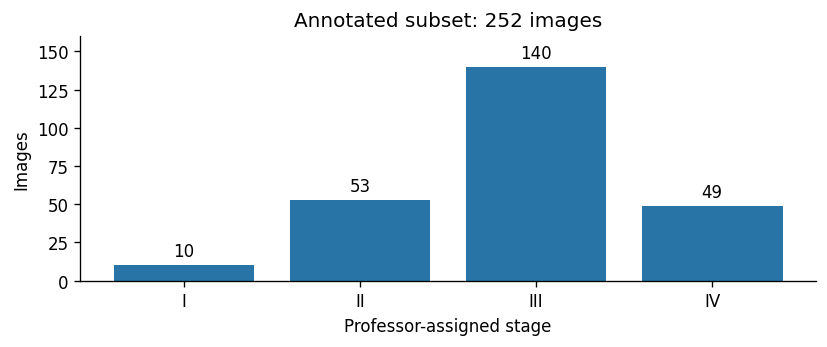

stage_2017  1   2   3   4
fold                     
0           2  11  28  10
1           2  11  28  10
2           2  11  28   9
3           2  10  28  10
4           2  10  28  10


In [2]:
counts=samples.stage_2017.value_counts().sort_index()
fig,ax=plt.subplots(figsize=(7,3))
bars=ax.bar(['I','II','III','IV'],counts,color=COLORS[0])
ax.bar_label(bars,padding=3)
ax.set(xlabel='Professor-assigned stage',ylabel='Images',
       title='Annotated subset: 252 images',ylim=(0,160))
plt.tight_layout(); plt.show()
print(pd.crosstab(samples.fold,samples.stage_2017).to_string())

## 2. Overall held-out performance
Macro F1 is the primary measure: every stage receives equal weight. Balanced accuracy averages the four stage recalls. Ordinary accuracy is dominated by the largest class, Stage III. Lower stage MAE is better.

                  Accuracy  Bal. acc.  Macro F1  Stage MAE  Weighted kappa
EfficientNet        0.5833     0.5170    0.4926     0.4286          0.6443
DINOv2 whole        0.6071     0.4589    0.4535     0.4167          0.5948
DINOv2 + regions    0.6310     0.4990    0.4948     0.3889          0.6130
Always predicting Stage III: 55.56% accuracy; 25% balanced accuracy.


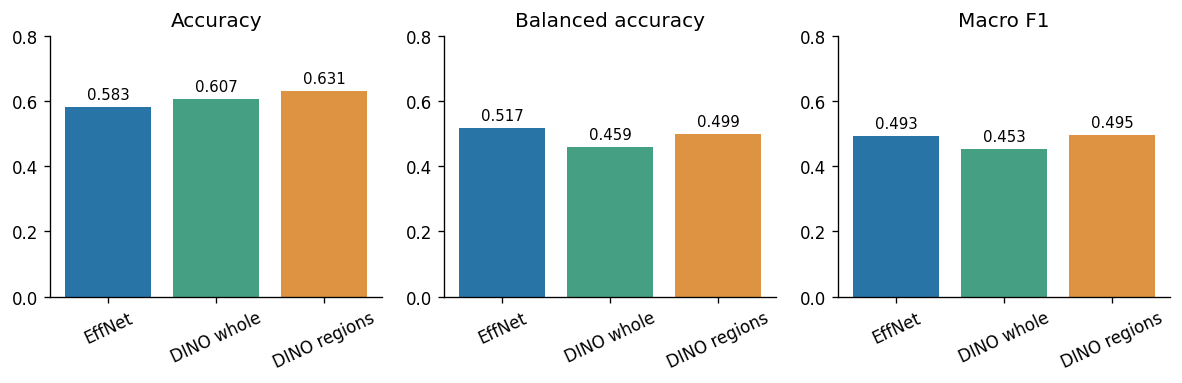

In [3]:
keys=['accuracy','balanced_accuracy','macro_f1','ordinal_mae',
      'quadratic_weighted_kappa']
summary=pd.DataFrame([[reports[m][k] for k in keys] for m in METHODS],
                     index=NAMES,columns=['Accuracy','Bal. acc.','Macro F1',
                                          'Stage MAE','Weighted kappa'])
print(summary.round(4).to_string())
print('Always predicting Stage III: 55.56% accuracy; 25% balanced accuracy.')
fig,axes=plt.subplots(1,3,figsize=(10,3.3))
for ax,key,title in zip(axes,keys[:3],['Accuracy','Balanced accuracy','Macro F1']):
    bars=ax.bar(range(3),[reports[m][key] for m in METHODS],color=COLORS)
    ax.bar_label(bars,fmt='%.3f',padding=3,fontsize=9)
    ax.set(xticks=range(3),xticklabels=['EffNet','DINO whole','DINO regions'],
           ylim=(0,.8),title=title)
    ax.tick_params(axis='x',rotation=25)
plt.tight_layout(); plt.show()

## 3. Stage-specific recall
Regional DINOv2 recognizes more Stage III cases. EfficientNet retains higher Stage I and Stage IV recall. No approach recognizes Stage I reliably: 2/10, 0/10 and 1/10 cases are correctly classified, respectively. The higher overall accuracy is not a gain across every stage.

           EfficientNet  DINOv2 whole  DINOv2 + regions
Stage I            20.0           0.0              10.0
Stage II           52.8          49.1              50.9
Stage III          56.4          67.1              69.3
Stage IV           77.6          67.3              69.4


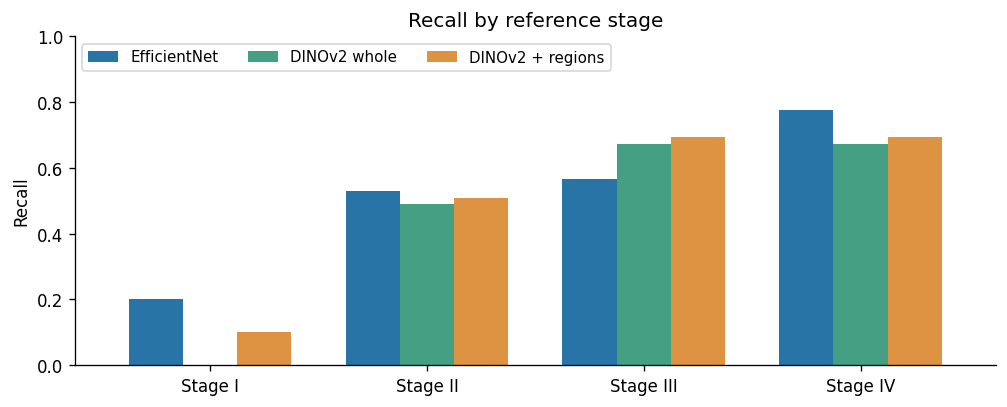

In [4]:
recall=pd.DataFrame({name:[reports[m]['per_stage'][str(k)]['recall']
                         for k in range(1,5)]
                     for m,name in zip(METHODS,NAMES)},
                    index=['Stage I','Stage II','Stage III','Stage IV'])
print((recall*100).round(1).to_string())
ax=recall.plot.bar(figsize=(8.5,3.5),color=COLORS,width=.75)
ax.set(ylabel='Recall',ylim=(0,1),title='Recall by reference stage')
ax.tick_params(axis='x',rotation=0)
ax.legend(loc='upper left',ncol=3,fontsize=9)
plt.tight_layout(); plt.show()

## 4. Confusion matrices
Rows are reference stages; columns are predictions. Counts make the small Stage I sample visible. All matrices use the same color scale.

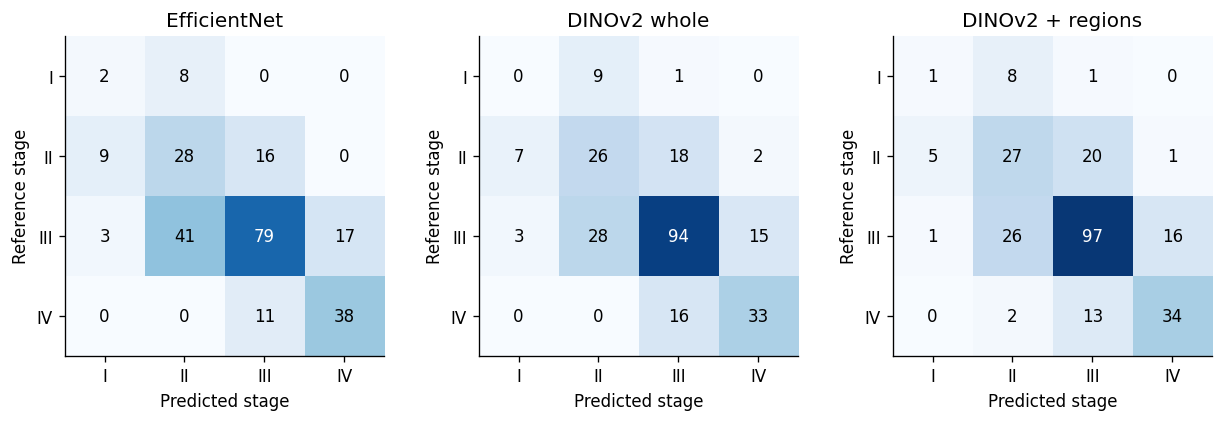

In [5]:
fig,axes=plt.subplots(1,3,figsize=(10.5,3.4))
for ax,m,name in zip(axes,METHODS,NAMES):
    cm=confusion_matrix(pred[m].stage_2017,pred[m].pred_stage,labels=[1,2,3,4])
    ax.imshow(cm,cmap='Blues',vmin=0,vmax=100)
    for i in range(4):
        for j in range(4):
            ax.text(j,i,str(cm[i,j]),ha='center',va='center',
                    color='white' if cm[i,j]>50 else 'black')
    ax.set(xticks=range(4),yticks=range(4),xticklabels=['I','II','III','IV'],
           yticklabels=['I','II','III','IV'],xlabel='Predicted stage',
           ylabel='Reference stage',title=name)
plt.tight_layout(); plt.show()

## 5. Variation across folds
Each test fold has two Stage I cases. Regional DINOv2 varies substantially across folds; a pooled near-tie is not evidence of stable equivalence. Lines connect matched folds, not training epochs.

            EfficientNet  DINOv2 whole  DINOv2 + regions
Outer fold                                              
0                 0.4650        0.4117            0.3690
1                 0.3590        0.4924            0.5114
2                 0.5456        0.5077            0.4804
3                 0.5097        0.4385            0.6314
4                 0.4637        0.4203            0.4519


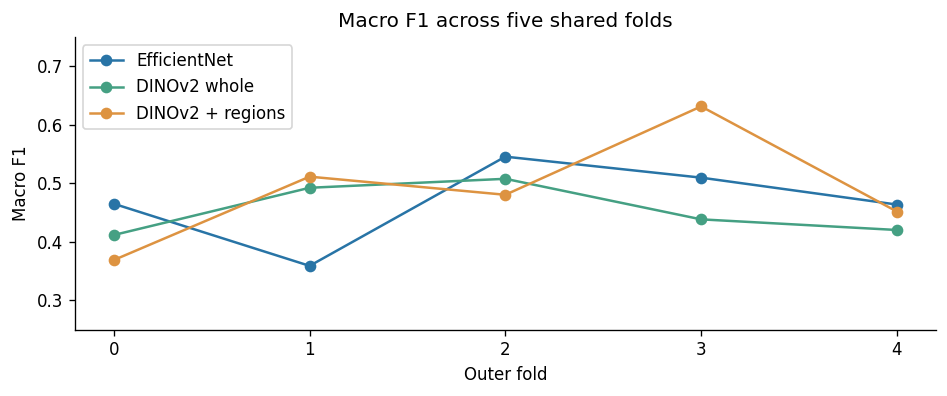

In [6]:
folds=pd.DataFrame({name:[reports[m]['fold_metrics'][str(f)]['macro_f1']
                         for f in range(5)]
                    for m,name in zip(METHODS,NAMES)})
print(folds.round(4).rename_axis('Outer fold').to_string())
ax=folds.plot(marker='o',color=COLORS,figsize=(8,3.4))
ax.set(xlabel='Outer fold',ylabel='Macro F1',xticks=range(5),
       ylim=(.25,.75),title='Macro F1 across five shared folds')
plt.tight_layout(); plt.show()

## 6. Paired uncertainty intervals
These conditional 95% intervals use 1,000 stratified patient-bootstrap resamples of fixed out-of-fold predictions. They exclude retraining variability and external generalization. Both span zero: neither DINOv2 variant demonstrates superiority over EfficientNet. This is not an equivalence test.

Method vs EfficientNet  Difference  Lower 95%  Upper 95%
          DINOv2 whole     -0.0392    -0.1172     0.0330
      DINOv2 + regions      0.0021    -0.0689     0.0689


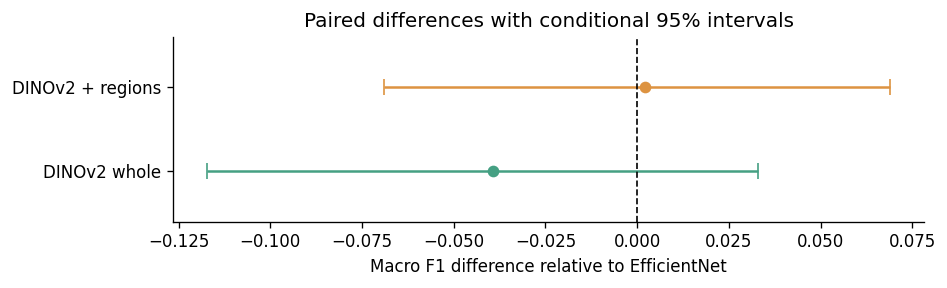

In [7]:
rows=[]
for m,name in zip(METHODS[1:],NAMES[1:]):
    p=paired[m]; lo,hi=p['conditional_95pct_interval']
    rows.append([name,p['macro_f1_difference'],lo,hi])
print(pd.DataFrame(rows,columns=['Method vs EfficientNet','Difference',
                                 'Lower 95%','Upper 95%']).round(4).to_string(index=False))
fig,ax=plt.subplots(figsize=(8,2.5))
for y,(_,delta,lo,hi) in enumerate(rows):
    ax.errorbar(delta,y,xerr=[[delta-lo],[hi-delta]],fmt='o',
                capsize=5,color=COLORS[y+1])
ax.axvline(0,color='black',linestyle='--',linewidth=1)
ax.set(yticks=[0,1],yticklabels=[r[0] for r in rows],ylim=(-.6,1.6),
       xlabel='Macro F1 difference relative to EfficientNet',
       title='Paired differences with conditional 95% intervals')
plt.tight_layout(); plt.show()

## 7. Selected settings and historical pilot
EfficientNet selected its epoch on internal validation data and then refitted from clean initialization on all development images. DINOv2 selected regularization using three inner folds.

The earlier notebook's 73.7% accuracy comes from a different 38-image pilot test set and an old BRAR checkpoint with unestablished training membership. Its split, preprocessing and initialization differ. Do not rank that figure directly against this five-fold comparison.

In [8]:
selected=[]
for f in range(5):
    row={'Fold':f}
    for m,name in zip(METHODS,NAMES):
        s=json.loads((ROOT/'small_data_pipeline/artifacts/runs'/m/
                      f'fold_{f}'/'selection.json').read_text())
        key='EffNet epochs' if m=='efficientnet' else name+' C'
        row[key]=s['best_epoch'] if m=='efficientnet' else s['best_C']
    selected.append(row)
print(pd.DataFrame(selected).to_string(index=False))
old=json.loads((ROOT/'runs/2017_classification/efficientnet_b4/eval_test/metrics.json').read_text())
print('Historical pilot ONLY:',old['num_samples'],'images; accuracy',
      round(old['accuracy'],4),'; macro F1',round(old['f1_macro'],4))

 Fold  EffNet epochs  DINOv2 whole C  DINOv2 + regions C
    0              6            0.10                0.01
    1             20           10.00                0.01
    2             17            0.01                1.00
    3             10            0.01                0.01
    4              6            0.01                1.00
Historical pilot ONLY: 38 images; accuracy 0.7368 ; macro F1 0.5282


## 8. Conclusion and thesis interpretation
- Keep EfficientNet-B4 as the primary CNN reference and report both DINOv2 comparisons.
- Regional DINOv2 reaches 63.1% accuracy, but macro F1 is 0.495 versus EfficientNet's 0.493. A clear improvement in the primary measure was not demonstrated.
- Stage I recognition remains inadequate. More accurate Stage III recognition accounts for much of the regional model's accuracy advantage.
- Report this as an exploratory small-data comparison. Do not omit unfavorable results or substitute the higher historical pilot accuracy.
- State the level_3-only subset, scarce Stage I examples, label/metadata disagreement, patient-identifier assumption and lack of external validation.

All 15 checkpoints were previously reloaded and reproduced their held-out predictions: identical predicted classes, maximum probability difference below 3e-8. The audit is saved in small_data_pipeline/artifacts/checks/trained_checkpoints.json.

Source evidence: small_data_pipeline/artifacts/data, runs and evaluation. Rerunning this notebook performs analysis only.